# Quasi-Stationary Oxygen Diffusion
## Breathing Dynamics in Pulmonary Acinus

Breathing modulates the alveolar oxygen concentration. In the quasi-stationary approximation the field adapts instantaneously, so at each time $t$ we solve $\Delta u = 0$ with

$$u(x, L, t) = C_a - C_b + C_1\,(\cos\omega t - 1)$$

and the other boundary conditions unchanged. The problem is linear, so the field (and the flux) is simply proportional to the boundary value: one linear solve per geometry is enough.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the package importable without installing it (pip install -e . also works)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from IPython.display import HTML
from matplotlib.animation import FuncAnimation

from acinus_diffusion import (PhysicalConstants as P, calculate_oxygen_flux,
                              grid_spacing, solve_quasistationary_diffusion)

print("Quasi-Stationary Oxygen Diffusion with Breathing Dynamics")
print("=" * 60)

Quasi-Stationary Oxygen Diffusion with Breathing Dynamics


## 1. Physiological Breathing Parameters

In [2]:
L = 0.01  # 1 cm domain
period_rest = 1 / P.BREATHING_RATE_REST
diffusion_time = L**2 / P.D_O2_AIR

print(f"Resting breathing rate:  {P.BREATHING_RATE_REST} Hz "
      f"({P.BREATHING_RATE_REST * 60:.0f} breaths/min), ω = {P.OMEGA_REST:.2f} rad/s")
print(f"Exercise breathing rate: {P.BREATHING_RATE_EXERCISE} Hz "
      f"({P.BREATHING_RATE_EXERCISE * 60:.0f} breaths/min), ω = {P.OMEGA_EXERCISE:.2f} rad/s")
print(f"Breathing amplitude C_1: {P.C_REST} mol/m³")
print(f"\nDiffusion time L²/D: {diffusion_time:.1f} s, breathing period: {period_rest:.1f} s")

Resting breathing rate:  0.3 Hz (18 breaths/min), ω = 1.88 rad/s
Exercise breathing rate: 0.5 Hz (30 breaths/min), ω = 3.14 rad/s
Breathing amplitude C_1: 4.2 mol/m³

Diffusion time L²/D: 5.0 s, breathing period: 3.3 s


**Validity of the approximation.** The quasi-stationary approximation requires the diffusion time $L^2/D$ to be small compared with the breathing period. For a 1 cm domain the two are of the same order, so the results below are a first approximation: a full time-dependent solution would show a damped and delayed response. For a smaller acinar unit ($L \approx 3$ mm, $L^2/D \approx 0.5$ s) the approximation is well justified.

## 2. Single Breathing Cycle Analysis

In [3]:
N, M = 80, 80
dx, dy = grid_spacing(N, M, L)

time_points = np.linspace(0, period_rest, 8, endpoint=False)
concentrations = []
boundary_values = []
flux_values = []

for t in time_points:
    C, C_top = solve_quasistationary_diffusion(N, M, L, t)
    concentrations.append(C)
    boundary_values.append(C_top)
    flux_values.append(calculate_oxygen_flux(C, dx, P.LAMBDA_TYPICAL))
    print(f"t = {t:.2f} s (phase {t / period_rest:.3f}): "
          f"boundary u = {C_top:.3f} mol/m³, flux = {flux_values[-1]:.3e} mol/(m·s)")

t = 0.00 s (phase 0.000): boundary u = 8.399 mol/m³, flux = 5.793e-06 mol/(m·s)
t = 0.42 s (phase 0.125): boundary u = 7.169 mol/m³, flux = 4.944e-06 mol/(m·s)
t = 0.83 s (phase 0.250): boundary u = 4.199 mol/m³, flux = 2.896e-06 mol/(m·s)
t = 1.25 s (phase 0.375): boundary u = 1.230 mol/m³, flux = 8.480e-07 mol/(m·s)
t = 1.67 s (phase 0.500): boundary u = -0.001 mol/m³, flux = -3.517e-10 mol/(m·s)
t = 2.08 s (phase 0.625): boundary u = 1.230 mol/m³, flux = 8.480e-07 mol/(m·s)
t = 2.50 s (phase 0.750): boundary u = 4.199 mol/m³, flux = 2.896e-06 mol/(m·s)
t = 2.92 s (phase 0.875): boundary u = 7.169 mol/m³, flux = 4.944e-06 mol/(m·s)


## 3. Visualization of the Breathing Cycle

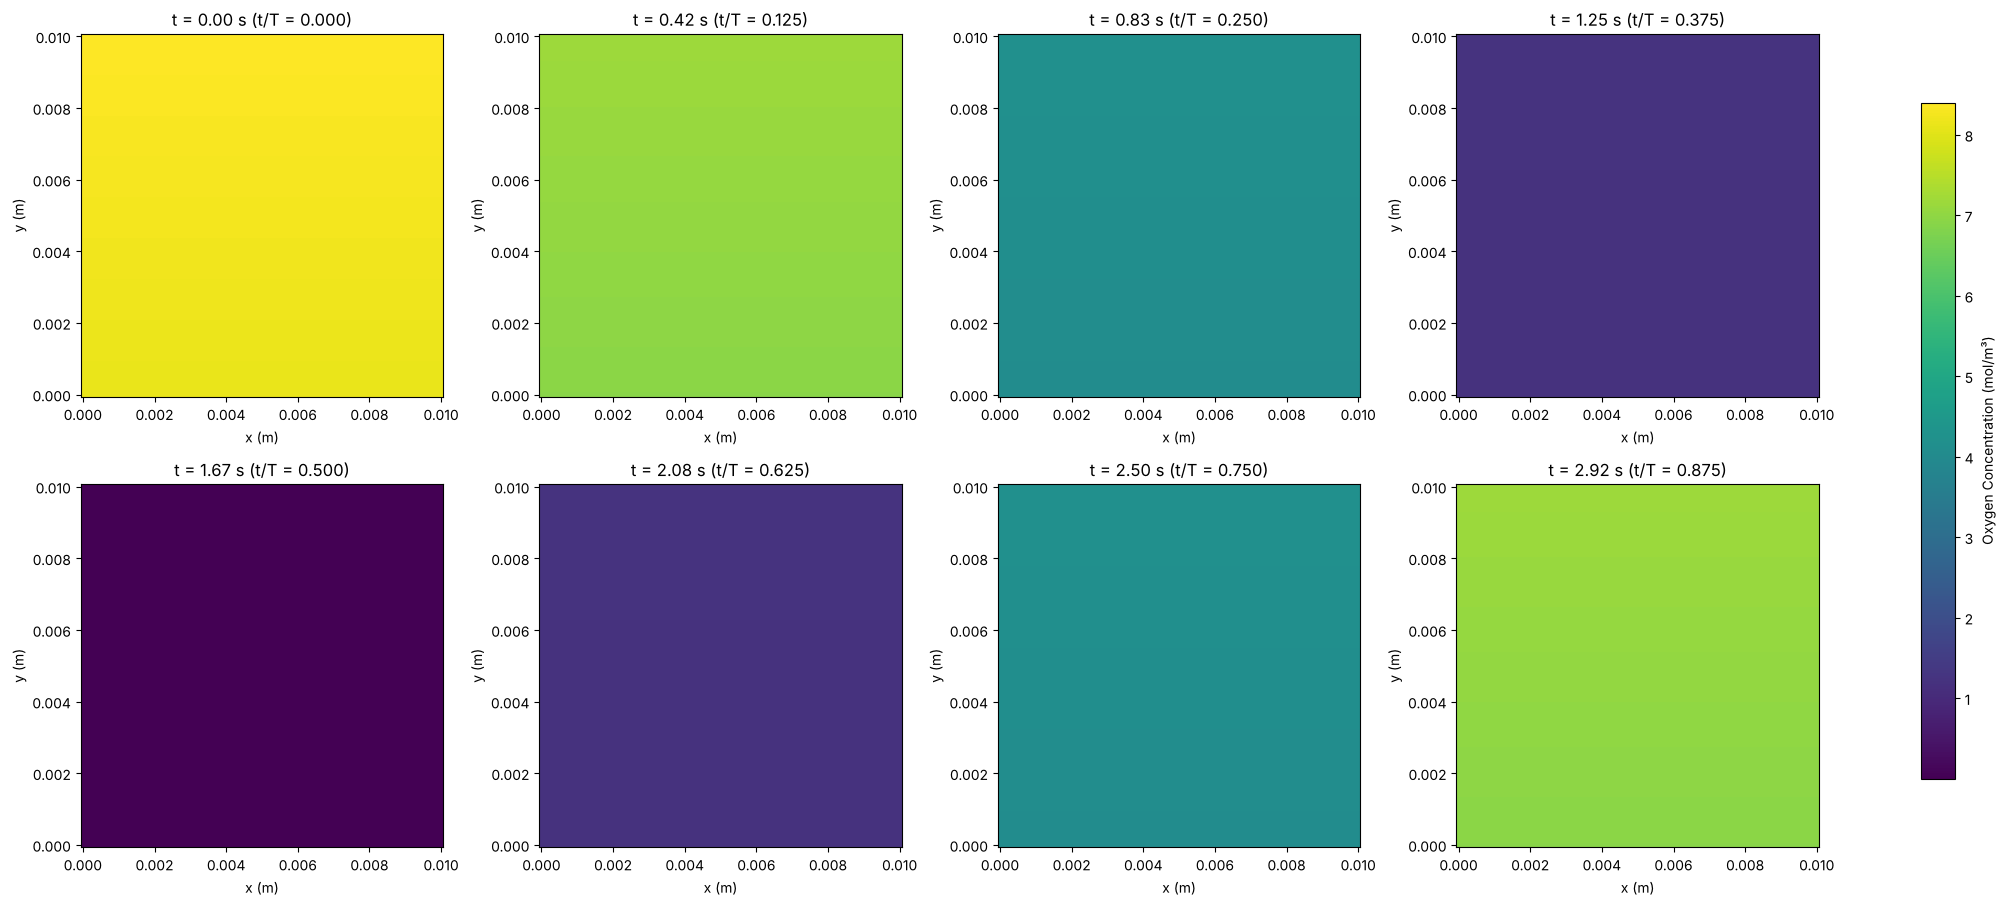

In [4]:
x = np.linspace(0, L, N)
y = np.linspace(0, L, M)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)

for ax, t, C in zip(axes.flat, time_points, concentrations):
    im = ax.pcolormesh(X, Y, C, shading='auto', cmap='viridis', vmin=P.C_BLOOD, vmax=P.C_AIR)
    ax.set_title(f't = {t:.2f} s (t/T = {t / period_rest:.3f})')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_aspect('equal')

fig.colorbar(im, ax=axes, label='Oxygen Concentration (mol/m³)', shrink=0.8)
plt.show()

## 4. Time Series Analysis

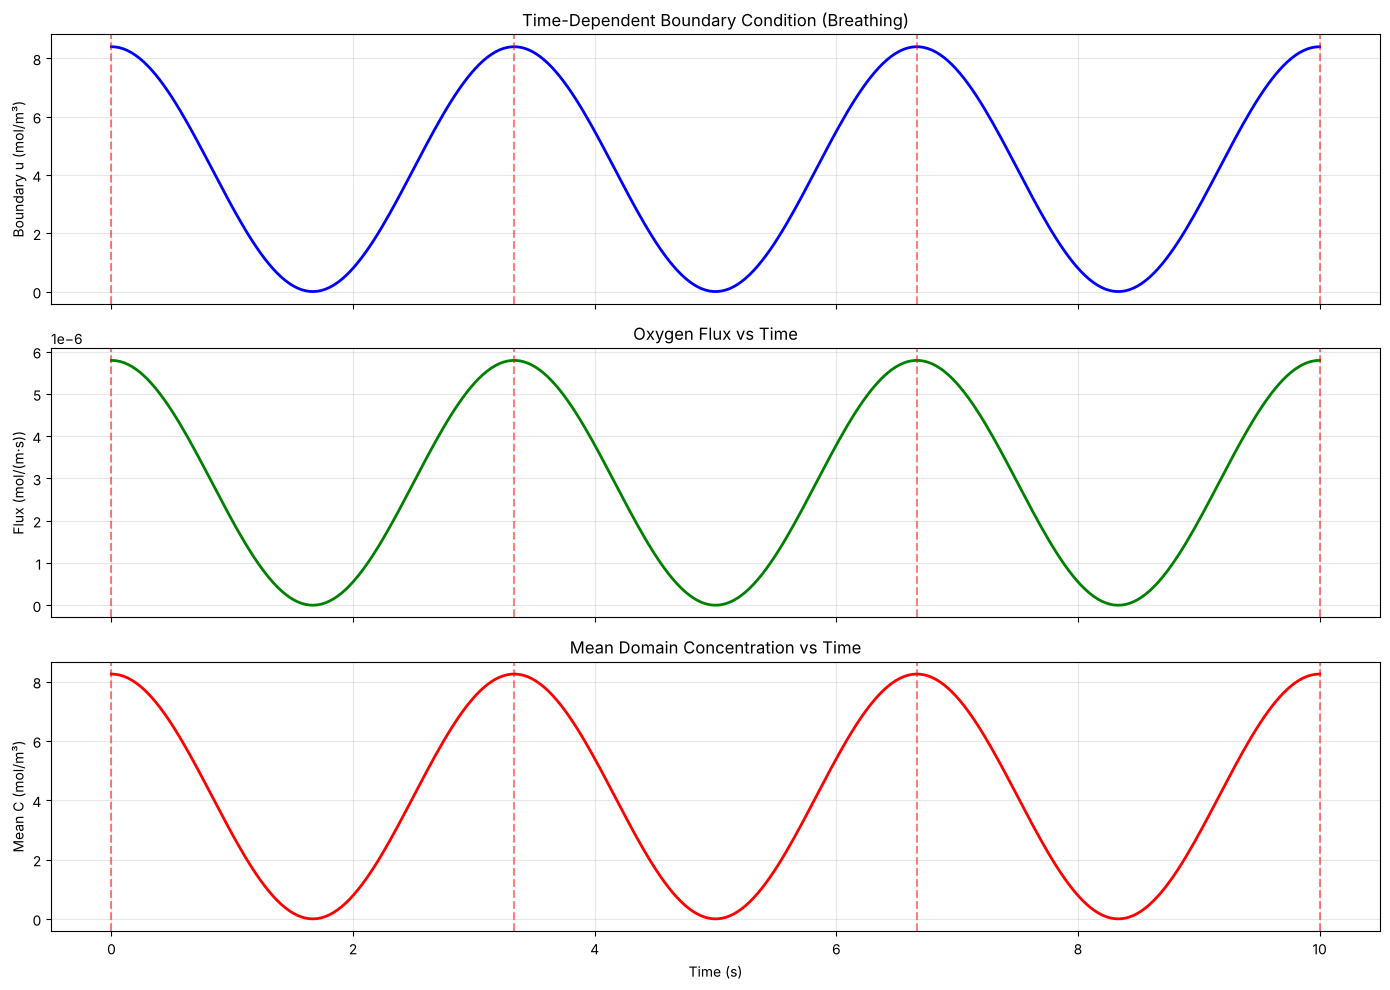

In [5]:
n_cycles = 3
time_series = np.linspace(0, n_cycles * period_rest, 300)

boundary_series = []
flux_series = []
mean_concentration_series = []

for t in time_series:
    C, C_top = solve_quasistationary_diffusion(N, M, L, t)
    boundary_series.append(C_top)
    flux_series.append(calculate_oxygen_flux(C, dx, P.LAMBDA_TYPICAL))
    mean_concentration_series.append(np.mean(C))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time_series, boundary_series, 'b-', linewidth=2)
axes[0].set_ylabel('Boundary u (mol/m³)')
axes[0].set_title('Time-Dependent Boundary Condition (Breathing)')

axes[1].plot(time_series, flux_series, 'g-', linewidth=2)
axes[1].set_ylabel('Flux (mol/(m·s))')
axes[1].set_title('Oxygen Flux vs Time')

axes[2].plot(time_series, mean_concentration_series, 'r-', linewidth=2)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Mean C (mol/m³)')
axes[2].set_title('Mean Domain Concentration vs Time')

for ax in axes:
    ax.grid(True, alpha=0.3)
    for i in range(n_cycles + 1):
        ax.axvline(x=i * period_rest, color='r', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

## 5. Breathing Rate Comparison

In the quasi-stationary regime the flux follows the boundary value instantaneously, $\Phi(t) \propto C_a - C_b + C_1(\cos\omega t - 1)$. Consequences:

* the flux curves of rest and exercise coincide when plotted against the phase $t/T$;
* the cycle-averaged flux is the flux for the mean boundary value $C_a - C_b - C_1$, **independent of the breathing rate**;
* there is no phase lag between boundary and flux.

A faster breathing rate can only change the exchange through effects not included here (finite diffusion time, larger tidal volume i.e. a larger $C_1$ or $C_a$).

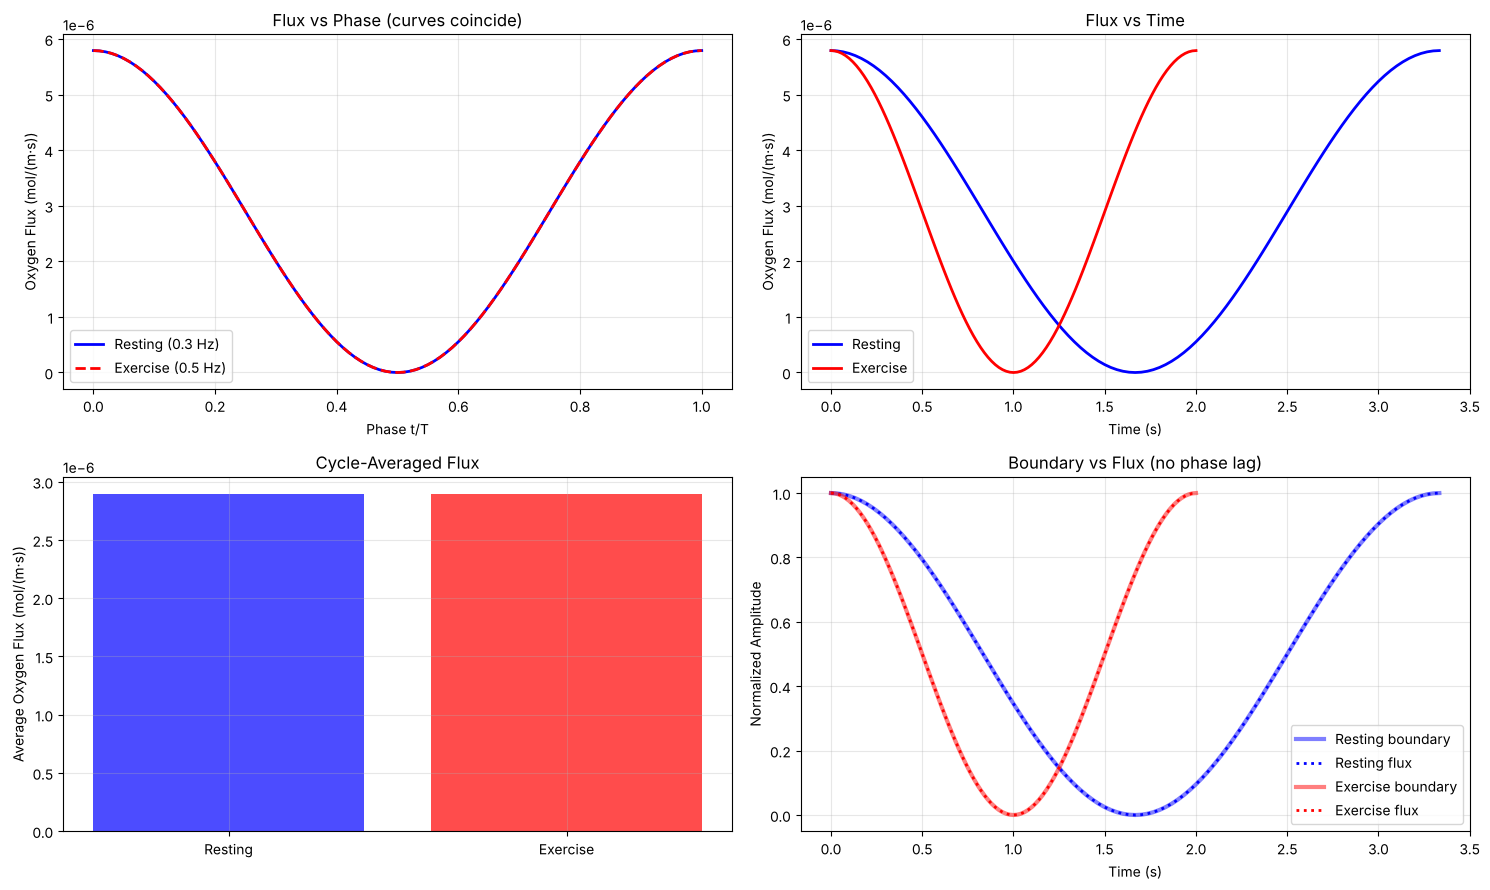

Resting  (0.3 Hz): average flux = 2.8962e-06 mol/(m·s)
Exercise (0.5 Hz): average flux = 2.8962e-06 mol/(m·s)
Flux for the mean boundary value:  2.8962e-06 mol/(m·s)


In [6]:
breathing_rates = [P.BREATHING_RATE_REST, P.BREATHING_RATE_EXERCISE]
rate_labels = ['Resting', 'Exercise']
colors = ['blue', 'red']
average_fluxes = []

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for rate, label, color in zip(breathing_rates, rate_labels, colors):
    omega = 2 * np.pi * rate
    period = 1 / rate
    t_cycle = np.linspace(0, period, 101)

    boundary_vals = []
    flux_vals = []
    for t in t_cycle:
        C, C_top = solve_quasistationary_diffusion(N, M, L, t, omega=omega)
        boundary_vals.append(C_top)
        flux_vals.append(calculate_oxygen_flux(C, dx, P.LAMBDA_TYPICAL))
    boundary_vals = np.array(boundary_vals)
    flux_vals = np.array(flux_vals)

    # Average over one period (the last point closes the cycle)
    average_fluxes.append(np.mean(flux_vals[:-1]))

    axes[0, 0].plot(t_cycle / period, flux_vals, color=color, linewidth=2,
                    linestyle='-' if label == 'Resting' else '--', label=f'{label} ({rate} Hz)')
    axes[0, 1].plot(t_cycle, flux_vals, color=color, linewidth=2, label=label)

    boundary_norm = (boundary_vals - boundary_vals.min()) / np.ptp(boundary_vals)
    flux_norm = (flux_vals - flux_vals.min()) / np.ptp(flux_vals)
    axes[1, 1].plot(t_cycle, boundary_norm, color=color, linestyle='-', linewidth=3,
                    alpha=0.5, label=f'{label} boundary')
    axes[1, 1].plot(t_cycle, flux_norm, color=color, linestyle=':', linewidth=2,
                    label=f'{label} flux')

axes[0, 0].set_xlabel('Phase t/T')
axes[0, 0].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[0, 0].set_title('Flux vs Phase (curves coincide)')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[0, 1].set_title('Flux vs Time')

axes[1, 0].bar(rate_labels, average_fluxes, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('Average Oxygen Flux (mol/(m·s))')
axes[1, 0].set_title('Cycle-Averaged Flux')

axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Normalized Amplitude')
axes[1, 1].set_title('Boundary vs Flux (no phase lag)')

for ax in (axes[0, 0], axes[0, 1], axes[1, 1]):
    ax.legend()
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

C_mean_bc, _ = solve_quasistationary_diffusion(N, M, L, 0, C_a=P.C_AIR - P.C_REST)
print(f"Resting  ({P.BREATHING_RATE_REST} Hz): average flux = {average_fluxes[0]:.4e} mol/(m·s)")
print(f"Exercise ({P.BREATHING_RATE_EXERCISE} Hz): average flux = {average_fluxes[1]:.4e} mol/(m·s)")
print(f"Flux for the mean boundary value:  {calculate_oxygen_flux(C_mean_bc, dx, P.LAMBDA_TYPICAL):.4e} mol/(m·s)")

## 6. Animation of Breathing Dynamics

In [7]:
N_anim = M_anim = 50
dx_anim, _ = grid_spacing(N_anim, M_anim, L)
n_frames = 30
frame_times = np.linspace(0, 2 * period_rest, n_frames)

x_anim = np.linspace(0, L, N_anim)
X_anim, Y_anim = np.meshgrid(x_anim, x_anim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi=60)

C_initial, _ = solve_quasistationary_diffusion(N_anim, M_anim, L, 0)
im = ax1.pcolormesh(X_anim, Y_anim, C_initial, shading='auto', cmap='viridis',
                    vmin=P.C_BLOOD, vmax=P.C_AIR)
fig.colorbar(im, ax=ax1, label='Oxygen Concentration (mol/m³)')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal')

line, = ax2.plot([], [], 'b-', linewidth=2)
ax2.set_xlim(0, frame_times[-1])
ax2.set_ylim(0, 1.1 * max(flux_series))
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Oxygen Flux (mol/(m·s))')
ax2.set_title('Oxygen Flux vs Time')
ax2.grid(True, alpha=0.3)

anim_times, anim_fluxes = [], []


def animate(frame):
    t = frame_times[frame]
    C, _ = solve_quasistationary_diffusion(N_anim, M_anim, L, t)
    im.set_array(C.ravel())
    ax1.set_title(f'Oxygen Concentration Field, t = {t:.2f} s')

    if frame == 0:
        anim_times.clear()
        anim_fluxes.clear()
    anim_times.append(t)
    anim_fluxes.append(calculate_oxygen_flux(C, dx_anim, P.LAMBDA_TYPICAL))
    line.set_data(anim_times, anim_fluxes)
    return im, line


anim = FuncAnimation(fig, animate, frames=n_frames, interval=100)
fig.tight_layout()
plt.close(fig)  # display only the interactive animation below
HTML(anim.to_jshtml())

## 7. Summary

* The breathing modulation is imposed through the alveolar boundary value and the field follows it in phase.
* The flux oscillates between $\Phi_{max}$ (at $\cos\omega t = 1$) and the flux for $C_a - C_b - 2C_1$.
* The cycle-averaged flux does not depend on the breathing rate within this approximation.
* The approximation is only marginally valid for a 1 cm domain ($L^2/D \approx 5$ s vs $T \approx 3.3$ s); it is accurate for smaller acinar units.

Next: COPD pathology modeling.